# PoC MVP 1 — Malla dental → nube de puntos → 3D Gaussian Splatting (VTK)

**Issue 2** · Contraparte de datos: [`docs/research/dataset-teeth3ds.md`](../docs/research/dataset-teeth3ds.md) · Diseño: [`docs/architecture/multi-agent-pipeline.md`](../docs/architecture/multi-agent-pipeline.md)

**Objetivo del PoC:** validar el eslabón mínimo del pipeline *«malla 3D → campo gaussiano volumétrico»* con la librería fácil (**VTK**, `vtkGaussianSplatter`), y comprobar que la salida se puede **serializar al contrato** `core-schemas` (`TwinSnapshot` + `gaussian_field_ref`), para que el PoC no quede huérfano de la arquitectura.

**Qué NO es:** no es 3DGS entrenado (no hay optimización diferenciable ni armónicos esféricos); es un *splatting* de densidad clásico que hace de **banco de pruebas** de la tubería y de insumo para el **ADR 002 (render)** y el ADR de fusión. Ver §Conclusiones.

**Entrada:** subconjunto Teeth3DS+ verificado en `data/raw/teeth3ds/` (gitignored). Licencia **CC-BY 4.0** (Ben-Hamadou et al., 2022) — atribuir en derivados.

**Pasos:** (0) entorno · (1) resolver caso cruzando los dos árboles · (2) cargar malla + labels FDI · (3) render por FDI · (4) `vtkGaussianSplatter` · (5) serializar al contrato · (6) conclusiones.

## 0 · Entorno

VTK renderiza **offscreen** (sin ventana) y mostramos PNG en línea — así el notebook corre headless (CI / servidor sin display). Silenciamos los avisos de VTK: los `.obj` de Teeth3DS traen color por vértice (`v x y z r g b`) y `vtkOBJReader` avisa por cada línea.

In [1]:
import json # lectura de fichero
import hashlib # calcular hash SHA-256 del artefacto que generamos al final
from pathlib import Path # manejo de rutas

import numpy as np # arrays numericos (etiquetas y coordenadas de los vertices)
import vtk # la libreria de visualizacion/geometria 3d
from vtk.util.numpy_support import numpy_to_vtk, vtk_to_numpy # puentes entre arrays de NumPy y las estructuras internas de VTK (VTK no usa NumPy nativamente)
from IPython.display import Image, display # para mostrar imagenes png incrustadas en la salida del notebook

vtk.vtkObject.GlobalWarningDisplayOff()  # calla el flood de avisos del OBJReader
# es necesario porque los .obj de Teeth3DS traen color por vértice (v x y z r g b) y el lector VTK escupe un warning por cada linea del
# fichero

# Raíz del repo: subir hasta encontrar data/raw
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent
MESH_ROOT = ROOT / "data/raw/teeth3ds/3D_scans_per_patient_obj_files"
LABEL_ROOT = ROOT / "data/raw/teeth3ds/ground-truth_labels_instances"
# los dos arboles apralelos del dataset: uno con mallas .obj, otro con las etiquetas .json
print("repo:", ROOT)
print("VTK :", vtk.vtkVersion.GetVTKVersion())
assert MESH_ROOT.exists() and LABEL_ROOT.exists(), "Falta el dataset (corre scripts/fetch_teeth3ds.sh)"


repo: /home/lgarbayo/agentic-smart-health
VTK : 9.6.2


Helper de render offscreen → PNG en línea:

In [2]:
# funcion render para dibujar 3D -> png
def render(actors, size=(700, 700), bg=(0.10, 0.10, 0.12), elevation=0.0):
    ren = vtk.vtkRenderer()
    for a in actors:
        ren.AddActor(a)
    ren.SetBackground(*bg)
    rw = vtk.vtkRenderWindow()
    rw.SetOffScreenRendering(1)
    rw.SetSize(*size)
    rw.AddRenderer(ren)
    ren.ResetCamera()
    if elevation:
        ren.GetActiveCamera().Elevation(elevation)
        ren.ResetCameraClippingRange()
    rw.Render()
    w2i = vtk.vtkWindowToImageFilter()
    w2i.SetInput(rw)
    w2i.Update()
    png = vtk.vtkPNGWriter()
    png.SetWriteToMemory(1)
    png.SetInputConnection(w2i.GetOutputPort())
    png.Write()
    data = bytes(memoryview(png.GetResult()))
    display(Image(data=data))

## 1 · Resolver un caso (cruzando los dos árboles)

Teeth3DS+ guarda mallas y labels en **dos árboles paralelos**; el loader empareja por `<ID>_<jaw>`. Regla de ingesta del diseño: *1 modalidad = 1 soporte = 1 agente* — aquí la malla `.obj` es soporte **superficial** (futuro `stl-agent`).

In [3]:
def resolve_case(patient_id: str, jaw: str) -> tuple[Path, Path]:
    obj = MESH_ROOT / patient_id / f"{patient_id}_{jaw}.obj"
    js = LABEL_ROOT / patient_id / f"{patient_id}_{jaw}.json"
    if not obj.exists() or not js.exists():
        raise FileNotFoundError(f"Caso incompleto: {patient_id}_{jaw}")
    return obj, js

# primer caso disponible (mandíbula)
PID = sorted(p.name for p in MESH_ROOT.iterdir() if p.is_dir())[0]
JAW = "lower"
obj_path, json_path = resolve_case(PID, JAW)
print("Caso:", f"{PID}_{JAW}")

Caso: 01A6GW4A_lower


## 2 · Cargar malla + labels FDI

`labels` es un array **por vértice** (mismo orden que los puntos de la malla): código ISO-FDI del diente, **`0` = encía**. Validan contra el `FDICode` del contrato.

In [4]:
def load_mesh(obj_path: Path) -> vtk.vtkPolyData:
    r = vtk.vtkOBJReader()
    r.SetFileName(str(obj_path))
    r.Update()
    return r.GetOutput()

poly = load_mesh(obj_path)
n_pts = poly.GetNumberOfPoints()
labels = np.asarray(json.load(open(json_path))["labels"], dtype=np.int32)
pts = vtk_to_numpy(poly.GetPoints().GetData())

assert len(labels) == n_pts, "labels no casan con vértices"
print(f"malla   : {n_pts:,} vértices · {poly.GetNumberOfCells():,} caras")
print(f"bbox    : min {pts.min(0).round(1)}  max {pts.max(0).round(1)} (mm)")
print(f"FDI     : {sorted(int(v) for v in np.unique(labels))}")
print(f"encía(0): {int((labels == 0).sum()):,} vértices")

# adjuntar FDI como escalares de punto para colorear
farr = numpy_to_vtk(labels.astype(float))
farr.SetName("FDI")
poly.GetPointData().SetScalars(farr)

malla   : 109,990 vértices · 219,880 caras
bbox    : min [ -44.4  -29.9 -121.3]  max [ 44.2  39.6 -82.2] (mm)
FDI     : [0, 31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 46, 47]
encía(0): 36,123 vértices


0

## 3 · Render de la malla coloreada por FDI

Validación visual de que el **ancla semántica** (`region_id` FDI) está bien alineada con la geometría: cada diente = un color; la encía (0) de fondo.

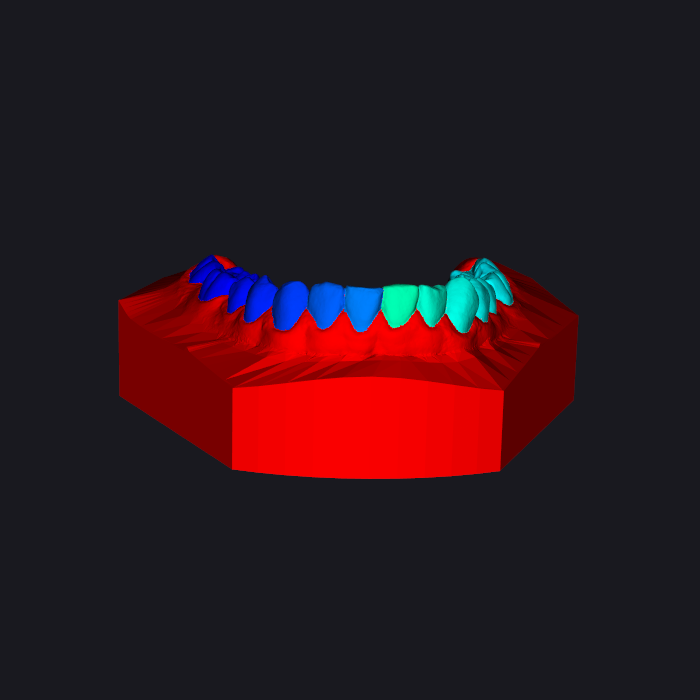

In [5]:
m = vtk.vtkPolyDataMapper()
m.SetInputData(poly)
m.SetScalarRange(0, 47)
a = vtk.vtkActor()
a.SetMapper(m)
render([a], elevation=-70)
# con esta celda se valida visualmente que la etiqueta coincide con la geometía de cada diente

## 3b · Malla (triángulos) vs. nube de puntos (vértices)

El **mismo diente** de dos formas, para ver la diferencia que sostiene el PoC:

- **Malla** (izq., wireframe): los **triángulos** que forman la superficie — vértices *conectados* por caras. Es lo que da la *forma*.
- **Nube de puntos** (der.): **solo los vértices**, sueltos. Es lo que alimenta a `vtkGaussianSplatter` — cada punto será el centro de una gaussiana.

La malla nos da la forma; los vértices son los «ladrillos» que convertimos en gaussianas, y cada uno trae pegada su etiqueta FDI.

diente FDI: 41
submalla: 3,128 vértices · 5,946 triángulos
malla (triángulos):


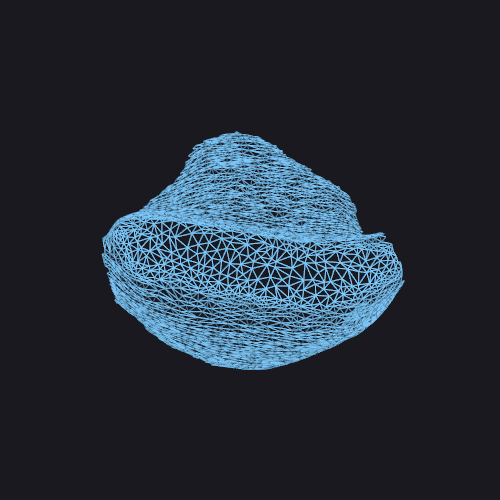

nube de puntos (vértices):


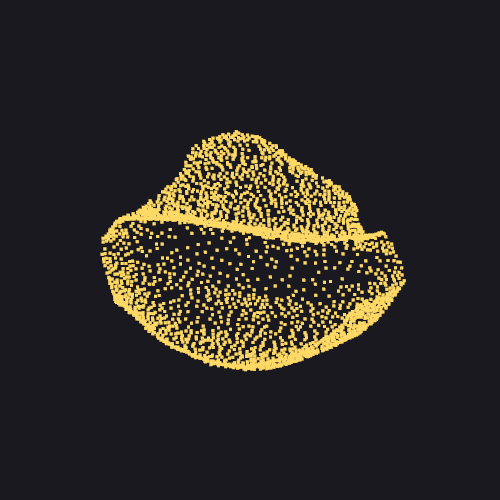

In [6]:
# Elegimos un diente presente y extraemos su submalla por la etiqueta FDI.
fdis = sorted(int(v) for v in np.unique(labels) if v != 0)
tooth = fdis[len(fdis) // 2]
print("diente FDI:", tooth)

thr = vtk.vtkThreshold()
thr.SetInputData(poly)
thr.SetInputArrayToProcess(0, 0, 0, vtk.vtkDataObject.FIELD_ASSOCIATION_POINTS, "FDI")
thr.SetLowerThreshold(tooth)
thr.SetUpperThreshold(tooth)
thr.SetAllScalars(1)  # toda la cara debe pertenecer a ese diente
thr.Update()
geo = vtk.vtkGeometryFilter()  # unstructured grid -> polydata (superficie)
geo.SetInputConnection(thr.GetOutputPort())
geo.Update()
tooth_poly = geo.GetOutput()
print(f"submalla: {tooth_poly.GetNumberOfPoints():,} vértices · {tooth_poly.GetNumberOfCells():,} triángulos")

# (a) MALLA — los triángulos (wireframe para verlos)
mm = vtk.vtkPolyDataMapper()
mm.SetInputData(tooth_poly)
mm.ScalarVisibilityOff()
mesh_actor = vtk.vtkActor()
mesh_actor.SetMapper(mm)
mesh_actor.GetProperty().SetRepresentationToWireframe()
mesh_actor.GetProperty().SetColor(0.5, 0.8, 1.0)
print("malla (triángulos):")
render([mesh_actor], size=(500, 500))

# (b) NUBE DE PUNTOS — solo los vértices (los ladrillos del splatting)
vg = vtk.vtkVertexGlyphFilter()
vg.SetInputData(tooth_poly)
vg.Update()
pm = vtk.vtkPolyDataMapper()
pm.SetInputConnection(vg.GetOutputPort())
pm.ScalarVisibilityOff()
pts_actor = vtk.vtkActor()
pts_actor.SetMapper(pm)
pts_actor.GetProperty().SetColor(1.0, 0.85, 0.4)
pts_actor.GetProperty().SetPointSize(3)
print("nube de puntos (vértices):")
render([pts_actor], size=(500, 500))

## 4 · `vtkGaussianSplatter` sobre la nube de puntos

El corazón del PoC: tomamos los vértices como **nube de puntos** y los *splatteamos* a un **campo escalar volumétrico** (cada punto siembra una gaussiana isótropa). Es el análogo clásico de la densidad σ que en RGS lleva cada primitiva (Beer-Lambert). Lo **contorneamos** (isosuperficie) para verlo.

volumen : (80, 80, 80) · rango densidad (0.0, 1.0)


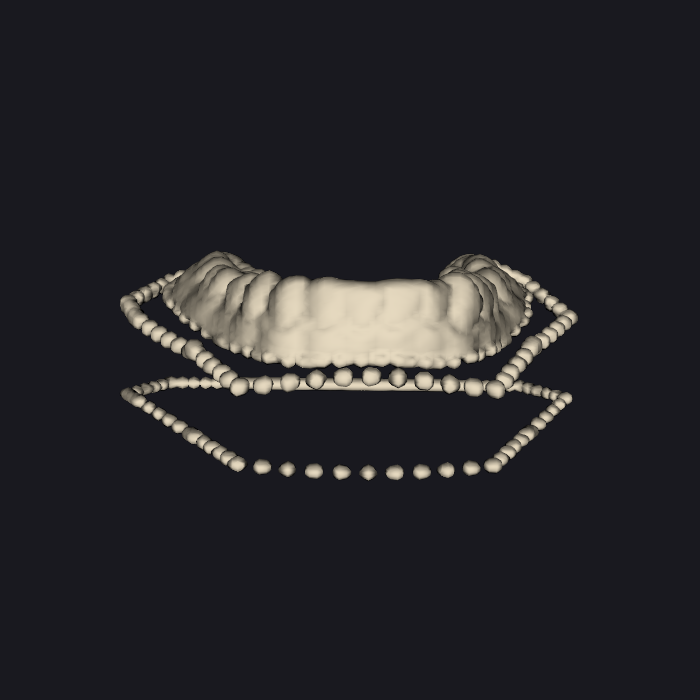

In [7]:
cloud = vtk.vtkPolyData()
cloud.SetPoints(poly.GetPoints()) # crea una nube de puntos a partir de los mismos vertices de la malla, pero sin las caras (solo puntos)
# es la entrada del splatter

splat = vtk.vtkGaussianSplatter() # siembra la gaussiana ("mancha" difusa) en cada punto y las acumula sobre la rejilla 3d
splat.SetInputData(cloud)
splat.SetSampleDimensions(80, 80, 80)  # resolución del volumen
splat.SetRadius(0.025)                 # soporte de cada gaussiana (frac. del bbox)
splat.ScalarWarpingOff()
splat.Update()
vol = splat.GetOutput()
print("volumen :", vol.GetDimensions(), "· rango densidad", tuple(round(x, 3) for x in vol.GetScalarRange()))

iso = vtk.vtkContourFilter()
iso.SetInputData(vol)
iso.SetValue(0, 0.15)
iso.Update()
im = vtk.vtkPolyDataMapper()
im.SetInputConnection(iso.GetOutputPort())
im.ScalarVisibilityOff()
ia = vtk.vtkActor()
ia.SetMapper(im)
ia.GetProperty().SetColor(0.90, 0.85, 0.75)
render([ia], elevation=-70)

## 5 · Serializar al contrato (`core-schemas`)

El fix de *«PoC sin huérfanos»*: la salida se referencia desde el contrato. Persistimos la nube como artefacto `.ply` en `data/processed/` (gitignored), la identificamos por **hash**, y construimos un `TwinSnapshot` cuyo `gaussian_field_ref` apunta a ese artefacto — exactamente el patrón del diseño (el campo masivo **no** se embebe en Pydantic; se referencia). Una muestra de `GaussianPrimitive` demuestra que la geometría + el `region_id` FDI encajan en la primitiva.

In [8]:
import sys
from datetime import datetime, timezone

sys.path.insert(0, str(ROOT / "packages/core-schemas/src"))
from core_schemas import GaussianPrimitive, Modality, Provenance, TwinSnapshot

# artefacto .ply (el "campo gaussiano" del PoC) + hash
art_dir = ROOT / "data/processed/teeth3ds"
art_dir.mkdir(parents=True, exist_ok=True)
ply_path = art_dir / f"{PID}_{JAW}_points.ply"
w = vtk.vtkPLYWriter()
w.SetFileName(str(ply_path))
w.SetInputData(cloud)
w.Write()
digest = hashlib.sha256(ply_path.read_bytes()).hexdigest()[:16]
print("artefacto:", ply_path.relative_to(ROOT), "· sha256", digest)

# muestra de primitivas (geometría + ancla FDI); region_id None para la encía
def fdi(v: int) -> str | None:
    return str(int(v)) if v != 0 else None

sample = [
    GaussianPrimitive(
        center=tuple(float(x) for x in pts[i]),
        scale=(0.02, 0.02, 0.02),
        rotation=(1.0, 0.0, 0.0, 0.0),
        density=float(0.5),
        region_id=fdi(labels[i]),
    )
    for i in range(0, n_pts, n_pts // 5)
]
print("primitivas ejemplo:", [p.region_id for p in sample])

snap = TwinSnapshot(
    acquisition_id=f"{PID}_{JAW}_poc",
    timestamp=datetime.now(timezone.utc),
    modalities=[Modality.STL],
    gaussian_field_ref=f"ply://{ply_path.name}#sha256:{digest}",
    n_primitives=n_pts,
    provenance=Provenance(
        source_file=str(obj_path.relative_to(ROOT)),
        modality=Modality.STL,
        agent="vtk-3dgs-poc",
        confidence=0.5,
    ),
)
print(snap.model_dump_json(indent=2))

artefacto: data/processed/teeth3ds/01A6GW4A_lower_points.ply · sha256 ed52a5fb9fd30aee
primitivas ejemplo: ['36', None, '31', '44', '34']
{
  "acquisition_id": "01A6GW4A_lower_poc",
  "timestamp": "2026-07-16T10:19:29.414604Z",
  "modalities": [
    "stl"
  ],
  "gaussian_field_ref": "ply://01A6GW4A_lower_points.ply#sha256:ed52a5fb9fd30aee",
  "n_primitives": 109990,
  "regional": [],
  "provenance": {
    "source_file": "data/raw/teeth3ds/3D_scans_per_patient_obj_files/01A6GW4A/01A6GW4A_lower.obj",
    "modality": "stl",
    "agent": "vtk-3dgs-poc",
    "confidence": 0.5,
    "ingested_at": "2026-07-16T10:19:29.414638Z"
  }
}


## 6 · Conclusiones (insumo para los ADR)

**Validado.** VTK carga las mallas Teeth3DS+, el ancla FDI casa vértice a vértice, `vtkGaussianSplatter` produce un campo de densidad volumétrico reconocible y la salida serializa limpiamente al contrato `core-schemas`.

**Límites observados (insumo del ADR 002 · render):**
- `vtkGaussianSplatter` es *splatting de densidad clásico*, **no** 3DGS entrenado: gaussianas **isótropas**, sin covarianza anisótropa, sin optimización diferenciable ni armónicos esféricos. Sirve como banco de pruebas y baseline, no como motor final.
- El resultado depende mucho de `Radius` / `SampleDimensions` (coste memoria O(n³)). Para 3DGS real habrá que evaluar un motor diferenciable (SPARK / gsplat) → **D1** del diseño.
- Los `.obj` traen **color por vértice** (aún sin usar): alimenta el canal `color_superficie` (soporte superficial) cuando se aborde la fusión.

**Ganado para siguientes eslabones:**
- Los labels FDI son **ground truth de `region_id` listo** para el `segmentation-agent` y para el **ancla semántica de la fusión** (D2).
- La encía (`instance`/`label` 0) es **aislable** → base del futuro PoC de inflamación/pH (capa regional).
- El truco *«solo fotos»*: con la malla + GT se pueden **renderizar vistas sintéticas** (este mismo `render()` offscreen) para alimentar un pipeline foto→3DGS con verdad-terreno.

**Siguiente:** Issue 3 (visor web three.js / GaussianSplats3D) y, tras el spike de motores, **ADR 002**.